# H07：事件概率训练与现有 L2 分组消融

本 Notebook 执行 [研究卷宗 H07](README.md#h07-事件概率训练与现有l2分组消融)。
唯一结论 owner 为该段；这里保存可执行过程及实验事实。

## 结果摘要

已完成20配置、160次月度拟合和151日全池预测。历史复核17日的Precision下界：

| 同结构浅树 | 纯日频 | 日频＋全部L2 |
| --- | ---: | ---: |
| 排名回归 | 33.76% | 34.35% |
| 事件概率分类 | 39.65% | 41.29% |

事件分类加全部L2的保守增量为 **+1.41个百分点**，5日区块95%包络 **[−0.94,+4.35]**；
开发134日则为 **−0.78点**。两分类器均未达到预先固定的“两段均≥2点且校正下界>0”。
Ridge单独加入活跃度/规模组的保守增量为开发 **+1.31点**、复核 **+2.00点**，
是本轮保留的分组线索，开发段未达到2点门槛。

输入为H06已消费历史，区间均为探索性名义区间。最高价标签表示潜在上冲机会，不表示能在最高价卖出或获得净收益。
完整判定、失败及下一步以卷宗H07为准。

## 证据说明索引

以下说明于 2026-09-24 从同主题 README 整理迁入，保存各节标注日期的方案、事实与当时解释；迁移不是新的运行或事前登记。当前假设、状态、结论和决定由 [README](README.md) 拥有。历史归档中的源码、Notebook、输入、验收快照和保留期继续有效，精确复现按对应归档说明执行。

- [H07 2026-09-23 冻结方案与验收](#h07-protocol)
- [H07 2026-09-23 结果、原因区分与归档](#h07-evidence)
- [H07 复跑与证据检查](#h07-reproduce)


## 1. 方法、固定参数与来源

B组213目标日；开发134日与历史复核17日均保留，月度扩展历史至少60个成熟日期。
四学习器 × 五输入集，无调参。匹配浅树结构用于区分目标变化；Logistic/Ridge 同时改变损失与链接。
正式预处理沿用0.5填充，日期等权；20模型全部披露。

### 关键假设

输入及标签分别假设P/T+1的22:00可用，T的09:00模型就绪；没有历史接收日志证明。
仅使用冻结更正版本，不接入正式数据/模型目录。模型推理和选择不消费未来标签。
最低有用增量为2个百分点（每天多命中1/50），只是研究筛选门槛。

方法 API 与本地锁定版本核对：[LogisticRegression 1.8](https://scikit-learn.org/1.8/modules/generated/sklearn.linear_model.LogisticRegression.html)、
[HistGradientBoostingClassifier 1.8](https://scikit-learn.org/1.8/modules/generated/sklearn.ensemble.HistGradientBoostingClassifier.html)。

In [1]:
import hashlib
import importlib.metadata
import json
import math
import shutil
import subprocess
import tarfile
import tempfile
import time
import warnings
from datetime import date
from datetime import time as wall_time
from pathlib import Path
from typing import NamedTuple, TypedDict

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib import font_manager
from sklearn.ensemble import (
    HistGradientBoostingClassifier,
    HistGradientBoostingRegressor,
)
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    brier_score_loss,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
)
from threadpoolctl import threadpool_limits

from src.config.model_config import MissingConfig, PreprocessingConfig
from src.training.engines.preprocessing import FittedPreprocessor
from src.utils import table_ops
from src.utils.datetime_utils import DateTimeUtils

source_root = Path.cwd()
assert (source_root / "research/subscription-training/README.md").is_file()
prior = Path(
    "/home/wsw/app/research-evidence/subscription-next-high-2026-09-22-mg7mzsz2"
)
evidence_parent = Path("/home/wsw/app/research-evidence")
evidence = Path(
    tempfile.mkdtemp(prefix="subscription-event-2026-09-23-", dir=evidence_parent)
)
print(f"EVIDENCE={evidence}", flush=True)


def _sha256(path: Path) -> str:
    with path.open("rb") as stream:
        return hashlib.file_digest(stream, "sha256").hexdigest()


def _write_json(path: Path, payload: object) -> None:
    with path.open("x", encoding="utf-8") as stream:
        json.dump(payload, stream, ensure_ascii=False, indent=2, allow_nan=False)


class _Parameters(TypedDict):
    training_seed: int
    bootstrap_seed: int
    bootstrap_repeats: int
    blocks: list[int]
    k: int
    threshold: float
    minimum_increment: float
    families: list[str]
    groups: list[str]
    logistic: dict[str, float | str]
    ridge: dict[str, int | str]
    hist: dict[str, int | float | bool]
    no_independent_final: bool
    prior: str
    retention: str


class _InputRecord(TypedDict):
    path: str
    source: str
    sha256: str
    size_bytes: int


class _FittedCandidate(NamedTuple):
    estimator: (
        Ridge
        | LogisticRegression
        | HistGradientBoostingRegressor
        | HistGradientBoostingClassifier
    )
    preprocessor: FittedPreprocessor


parameters: _Parameters = {
    "training_seed": 20260919,
    "bootstrap_seed": 20260923,
    "bootstrap_repeats": 10000,
    "blocks": [5, 1, 3],
    "k": 50,
    "threshold": 0.9,
    "minimum_increment": 0.02,
    "families": ["ridge", "logistic", "hist_rank", "hist_event"],
    "groups": ["daily", "price", "activity", "direction", "all"],
    "logistic": {"C": 0.01, "solver": "lbfgs", "max_iter": 1000, "tol": 1e-8},
    "ridge": {"alpha": 100, "solver": "cholesky"},
    "hist": {
        "max_iter": 100,
        "max_leaf_nodes": 7,
        "max_depth": 3,
        "min_samples_leaf": 500,
        "learning_rate": 0.05,
        "l2_regularization": 10,
        "max_bins": 63,
        "early_stopping": False,
        "random_state": 20260919,
    },
    "no_independent_final": True,
    "prior": str(prior),
    "retention": "until user decision and review complete",
}
_write_json(evidence / "parameters.json", parameters)
shutil.copy2(
    source_root / "research/subscription-training/README.md",
    evidence / "preregistered-README.md",
)
shutil.copy2(
    source_root / "research/subscription-training/event_probability.ipynb",
    evidence / "source-event_probability.ipynb",
)
with tarfile.open(evidence / "source.tar", "w") as archive:
    for folder in ["src", "docs", "research/subscription-training"]:
        for path in sorted((source_root / folder).rglob("*")):
            if path.is_file() and "__pycache__" not in path.parts:
                archive.add(path, arcname=str(path.relative_to(source_root)))
    for name in ["AGENTS.md", "pyproject.toml", "uv.lock"]:
        archive.add(source_root / name, arcname=name)
versions = {
    name: importlib.metadata.version(name)
    for name in [
        "numpy",
        "pandas",
        "pyarrow",
        "scikit-learn",
        "scipy",
        "joblib",
        "matplotlib",
    ]
}
_write_json(
    evidence / "run.json",
    {
        "base_commit": subprocess.check_output(
            ["git", "rev-parse", "HEAD"], text=True
        ).strip(),
        "worktree_before": subprocess.check_output(
            ["git", "status", "--short"], text=True
        ),
        "source_sha256": _sha256(evidence / "source.tar"),
        "versions": versions,
        "preregistration_sha256": _sha256(evidence / "preregistered-README.md"),
    },
)
font_manager.fontManager.addfont(prior / "NotoSansCJKsc-Regular.otf")
plt.rcParams.update(
    {
        "font.family": "Noto Sans CJK SC",
        "font.size": 11,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.unicode_minus": False,
        "figure.dpi": 120,
    }
)
warnings.filterwarnings("error", category=ConvergenceWarning)
display(pd.Series(versions, name="锁定环境").to_frame())

EVIDENCE=/home/wsw/app/research-evidence/subscription-event-2026-09-23-00ysvads


,锁定环境
numpy,2.5.1
pandas,3.0.2
pyarrow,25.0.0
scikit-learn,1.8.0
scipy,1.16.3
joblib,1.5.3
matplotlib,3.10.8


## 2. 冻结输入与互斥特征分组

读取归档内容并验证原 manifest；只复制本实验需要的充分输入，不将面板伪装为正式存储根。
价格组8列，活跃度/规模组16列（含4个覆盖比），方向组8列；全部L2严格等于三组并集。
标签保留原null；严格大于0.9为事件，不重新排名。

In [2]:
manifest = {
    item["path"]: item
    for item in json.loads((prior / "artifact-manifest.json").read_text())
}
input_names = [
    "panel.parquet",
    "candidate-labels.parquet",
    "rank-daily.parquet",
    "frozen-schedule.json",
    "parameters.json",
    "artifact-manifest.json",
]
input_names += [
    str(path.relative_to(prior))
    for path in sorted((prior / "extended").rglob("*.parquet"))
    if "development-expanding" in path.parts
    or "followup-primary" in path.parts
    or "followup-ablation" in path.parts
]
input_names += [
    str(path.relative_to(prior))
    for path in sorted((prior / "extended").rglob("fit-schedule.json"))
    if "development-expanding" in path.parts
    or "followup-primary" in path.parts
    or "followup-ablation" in path.parts
]
inputs = evidence / "inputs"
inputs.mkdir()
input_records: list[_InputRecord] = []
for name in input_names:
    original, copied = prior / name, inputs / name
    digest = _sha256(original)
    if name != "artifact-manifest.json":
        assert digest == manifest[name]["sha256"], name
    copied.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(original, copied)
    assert _sha256(copied) == digest
    input_records.append(
        {
            "path": name,
            "source": str(original),
            "sha256": digest,
            "size_bytes": copied.stat().st_size,
        }
    )
_write_json(evidence / "input-manifest.json", input_records)
panel = pd.read_parquet(inputs / "panel.parquet")
labels = pd.read_parquet(inputs / "candidate-labels.parquet")
schedule = json.loads((inputs / "frozen-schedule.json").read_text())
development_dates = schedule["development"]["extended"]
followup_dates = schedule["followup"]["extended"]
assert len(development_dates) == 134 and len(followup_dates) == 17
assert panel.trade_date.nunique() == 213 and len(panel) == 1103651
table_ops.require_unique(panel, ("symbol", "trade_date"), who="H07 frozen panel")
aligned = panel[["symbol", "trade_date", "y_rank_return"]].merge(
    labels[["symbol", "trade_date", "high_rank"]],
    on=["symbol", "trade_date"],
    how="left",
    validate="one_to_one",
)
np.testing.assert_array_equal(
    aligned.y_rank_return.to_numpy(dtype=float), aligned.high_rank.to_numpy(dtype=float)
)
assert (panel.feature_ready_ts <= panel.allocation_ts).all()
assert (panel.source_date < panel.trade_date).all()
feature_columns = [column for column in panel if column.startswith("lag_")]
daily_columns = [column for column in feature_columns if column.startswith("lag_f_d_")]
l2_columns = [column for column in feature_columns if column.startswith("lag_f_l2_")]
price_columns = [
    column for column in l2_columns if "edge_vwap" in column or "high_low" in column
]
direction_columns = [column for column in l2_columns if "tick_signed" in column]
activity_columns = [
    column for column in l2_columns if column not in price_columns + direction_columns
]
assert list(
    map(len, [daily_columns, price_columns, activity_columns, direction_columns])
) == [7, 8, 16, 8]
group_features = {"daily": daily_columns}
for group, extra in [
    ("price", price_columns),
    ("activity", activity_columns),
    ("direction", direction_columns),
    ("all", l2_columns),
]:
    group_features[group] = [
        column for column in feature_columns if column in extra + daily_columns
    ]
assert group_features["all"] == feature_columns and len(feature_columns) == 39
assert not np.isinf(panel[feature_columns].to_numpy(dtype=float)).any()
assert panel.y_rank_return.dropna().between(0, 1, inclusive="right").all()
_write_json(evidence / "features.json", group_features)
rules = {
    "rule_amount": "baseline_amount",
    "rule_momentum": "baseline_momentum",
    "rule_reversal": "baseline_reversal",
    "rule_volatility": "lag_f_d_close_volatility_60d_asof_tminus1_rank",
    "rule_turnover": "lag_f_d_turnover_rate_mean_20d_asof_tminus1_rank",
}
model_names = [
    f"{family}__{group}"
    for family in parameters["families"]
    for group in parameters["groups"]
]
classifiers = [
    name for name in model_names if name.startswith(("logistic", "hist_event"))
]
panel_days = {day: frame for day, frame in panel.groupby("trade_date", sort=True)}
training_days = panel.groupby("trade_date").label_ready_ts.max()
(evidence / "models").mkdir()
(evidence / "predictions").mkdir()
display(
    pd.DataFrame(
        {"特征数": {name: len(columns) for name, columns in group_features.items()}}
    )
)
print(
    f"冻结{len(input_records)}份输入；{len(panel):,}股票日；{panel.y_rank_return.isna().sum():,}未知标签"
)

,特征数
daily,7
price,15
activity,23
direction,15
all,39


冻结177份输入；1,103,651股票日；1,534未知标签


## 3. 固定前向训练、预测及强规则冻结

一次拟合所有固定配置，保存每月模型及每个评价日的全池预测。
在首次读取历史复核日的结果前，仅据开发段冻结最强规则。概率基线为当前拟合样本的日期等权事件率。
收敛警告当作技术失败，不在失败后通过调参挑选结果。

In [3]:
def _selected(frame: pd.DataFrame, score: np.ndarray, count: int) -> np.ndarray:
    ranking = frame[["symbol"]].assign(score=score, position=np.arange(len(frame)))
    return (
        ranking.sort_values(
            ["score", "symbol"], ascending=[False, True], na_position="last"
        )
        .position.iloc[:count]
        .to_numpy()
    )


fitted_models: dict[str, _FittedCandidate] = {}
fit_records = []
fitted_month = ""
prior_probability = 0.0
with threadpool_limits(limits=1):
    for stage, dates in [
        ("development", development_dates),
        ("followup", followup_dates),
    ]:
        for target_day in dates:
            frame = panel_days[target_day]
            fit_start = DateTimeUtils.local_time_to_utc_epoch_us(
                wall_time(8), date.fromisoformat(target_day)
            )
            if target_day[:7] != fitted_month:
                training_dates = training_days.index[training_days < fit_start].tolist()
                assert len(training_dates) >= 60
                train = panel.loc[
                    panel.trade_date.isin(training_dates) & panel.y_rank_return.notna()
                ]
                assert (train.label_ready_ts < fit_start).all()
                day_counts = (
                    train.groupby("trade_date")
                    .trade_date.transform("size")
                    .to_numpy(dtype=float)
                )
                weights = 1 / day_counts
                weights /= weights.mean()
                event = train.y_rank_return.gt(parameters["threshold"]).to_numpy(
                    dtype=int
                )
                prior_probability = float(np.average(event, weights=weights))
                rank_target = train.y_rank_return.to_numpy(dtype=float)
                for group, columns in group_features.items():
                    preprocessor = FittedPreprocessor.fit(
                        train_X=train[columns],
                        config=PreprocessingConfig(
                            missing=MissingConfig(method="constant", fill_value=0.5)
                        ),
                    )
                    keep, transformed = preprocessor.transform(
                        train[columns].to_numpy(dtype=float)
                    )
                    assert keep.all()
                    for family in parameters["families"]:
                        name = f"{family}__{group}"
                        if family == "ridge":
                            estimator = Ridge(**parameters["ridge"])
                        elif family == "logistic":
                            estimator = LogisticRegression(**parameters["logistic"])
                        elif family == "hist_rank":
                            estimator = HistGradientBoostingRegressor(
                                **parameters["hist"]
                            )
                        else:
                            estimator = HistGradientBoostingClassifier(
                                **parameters["hist"]
                            )
                        started = time.perf_counter()
                        estimator.fit(
                            transformed,
                            event if name in classifiers else rank_target,
                            sample_weight=weights,
                        )
                        elapsed = time.perf_counter() - started
                        assert elapsed < 3600
                        model_path = evidence / "models" / f"{target_day}-{name}.joblib"
                        joblib.dump((estimator, preprocessor), model_path)
                        fitted_models[name] = _FittedCandidate(estimator, preprocessor)
                        fit_records.append(
                            {
                                "trade_date": target_day,
                                "method": name,
                                "training_dates": training_dates,
                                "train_rows": len(train),
                                "feature_names": columns,
                                "fit_start_ts": fit_start,
                                "scenario_model_ready_ts": int(
                                    frame.allocation_ts.iloc[0]
                                ),
                                "max_label_ready_ts": int(train.label_ready_ts.max()),
                                "fit_seconds": elapsed,
                                "params": estimator.get_params(),
                                "path": str(model_path.relative_to(evidence)),
                                "sha256": _sha256(model_path),
                                "prior_probability": prior_probability,
                                "iterations": np.asarray(estimator.n_iter_).tolist(),
                            }
                        )
                        print(
                            f"fit {target_day} {name} days={len(training_dates)} seconds={elapsed:.2f}",
                            flush=True,
                        )
                fitted_month = target_day[:7]
            prediction = frame[["symbol", "trade_date"]].copy()
            for name, (estimator, preprocessor) in fitted_models.items():
                keep, transformed = preprocessor.transform(
                    frame[list(preprocessor.feature_names)].to_numpy(dtype=float)
                )
                assert keep.all()
                score = (
                    estimator.predict_proba(transformed)[:, 1]
                    if name in classifiers
                    else estimator.predict(transformed)
                )
                assert np.isfinite(score).all()
                prediction[name] = score
            for name, column in rules.items():
                prediction[name] = frame[column].to_numpy(dtype=float)
            prediction["prior_probability"] = prior_probability
            prediction.to_parquet(
                evidence / "predictions" / f"{target_day}.parquet", index=False
            )
        if stage == "development":
            rule_development = []
            for day in development_dates:
                frame = panel_days[day]
                for name, column in rules.items():
                    selected = _selected(
                        frame, frame[column].to_numpy(dtype=float), parameters["k"]
                    )
                    lower = (
                        frame.y_rank_return.iloc[selected]
                        .gt(parameters["threshold"])
                        .fillna(False)
                        .mean()
                    )
                    rule_development.append(
                        {
                            "trade_date": day,
                            "method": name,
                            "precision_lower": float(lower),
                        }
                    )
            rule_ranking = (
                pd.DataFrame(rule_development)
                .groupby("method")
                .precision_lower.mean()
                .sort_values(ascending=False, kind="stable")
            )
            strongest_rule = rule_ranking.index[0]
            _write_json(
                evidence / "strongest-rule-frozen.json",
                {
                    "method": strongest_rule,
                    "development": rule_ranking.to_dict(),
                    "followup_evaluated": False,
                },
            )
            print(f"development strongest rule={strongest_rule}", flush=True)
_write_json(evidence / "fit-schedule.json", fit_records)
print(
    f"完成{len(fit_records)}次拟合、{len(development_dates) + len(followup_dates)}日全池预测"
)

fit 2026-02-03 ridge__daily days=60 seconds=0.02


fit 2026-02-03 logistic__daily days=60 seconds=0.26


fit 2026-02-03 hist_rank__daily days=60 seconds=0.64


fit 2026-02-03 hist_event__daily days=60 seconds=0.78


fit 2026-02-03 ridge__price days=60 seconds=0.03


...

fit 2026-09-01 ridge__all days=199 seconds=0.51


fit 2026-09-01 logistic__all days=199 seconds=14.26


fit 2026-09-01 hist_rank__all days=199 seconds=9.24


fit 2026-09-01 hist_event__all days=199 seconds=9.00


完成160次拟合、151日全池预测


## 4. 命中、缺失界与概率质量

Precision的分母固定50。Recall/F1/Lift按H05公式保留上下界，未知从不当作真实负例。
Brier/log loss在同一已知标签集合上按日期等权；校准箱使用每个日期总权重相同的样本权重，固定十等宽箱。
回归分数不被解释为概率。

In [4]:
def _metrics(
    labels: np.ndarray, selected: np.ndarray, threshold: float
) -> dict[str, float | int]:
    known = np.isfinite(labels)
    events = known & (labels > threshold)
    chosen = np.zeros(len(labels), dtype=bool)
    chosen[selected] = True
    hits = int(events[chosen].sum())
    unknown_selected = int((~known & chosen).sum())
    unknown_unselected = int((~known & ~chosen).sum())
    opportunities = int(events.sum())
    count = int(chosen.sum())
    assert opportunities > 0
    recall_lower = hits / (opportunities + unknown_unselected)
    recall_upper = (hits + unknown_selected) / (opportunities + unknown_selected)
    return {
        "pool_size": len(labels),
        "selected": count,
        "hits": hits,
        "unknown_selected": unknown_selected,
        "unknown_unselected": unknown_unselected,
        "opportunities": opportunities,
        "precision_lower": hits / count,
        "precision_upper": (hits + unknown_selected) / count,
        "recall_lower": recall_lower,
        "recall_upper": recall_upper,
        "f1_lower": 2 * hits / (count + opportunities + unknown_unselected),
        "f1_upper": 2
        * (hits + unknown_selected)
        / (count + opportunities + unknown_selected),
        "lift_lower": len(labels) / count * recall_lower,
        "lift_upper": len(labels) / count * recall_upper,
        "random_lower": opportunities / len(labels),
        "random_upper": (opportunities + unknown_selected + unknown_unselected)
        / len(labels),
    }


metric_rows, probability_rows, calibration_rows, selections, subgroup_rows = (
    [],
    [],
    [],
    [],
    [],
)
for stage, dates in [("development", development_dates), ("followup", followup_dates)]:
    for day in dates:
        frame = panel_days[day].reset_index(drop=True)
        prediction = pd.read_parquet(evidence / "predictions" / f"{day}.parquet")
        pd.testing.assert_frame_equal(
            prediction[["symbol", "trade_date"]], frame[["symbol", "trade_date"]]
        )
        ranks = frame.y_rank_return.to_numpy(dtype=float)
        known = np.isfinite(ranks)
        actual = (ranks[known] > parameters["threshold"]).astype(int)
        groups = {"code_prefix": frame.symbol.str[:2]}
        for dimension, column in [
            ("volatility", rules["rule_volatility"]),
            ("liquidity", "lag_f_d_log_amount_rank"),
        ]:
            groups[dimension] = (
                pd.cut(
                    frame[column],
                    [0, 0.2, 0.8, 1],
                    labels=["low20", "middle60", "high20"],
                )
                .astype("string")
                .fillna("missing")
            )
        for method in model_names + list(rules):
            selected = _selected(frame, prediction[method].to_numpy(), parameters["k"])
            selected_symbols = frame.symbol.iloc[selected].tolist()
            metric_rows.append(
                {
                    "stage": stage,
                    "trade_date": day,
                    "method": method,
                    **_metrics(ranks, selected, parameters["threshold"]),
                }
            )
            selections.append(
                {
                    "stage": stage,
                    "trade_date": day,
                    "method": method,
                    "symbols": selected_symbols,
                }
            )
            chosen = np.zeros(len(frame), dtype=bool)
            chosen[selected] = True
            for dimension, group_values in groups.items():
                for group in sorted(group_values.unique()):
                    members = group_values.eq(group).to_numpy(dtype=bool)
                    member_selected = members & chosen
                    subgroup_rows.append(
                        {
                            "stage": stage,
                            "trade_date": day,
                            "method": method,
                            "dimension": dimension,
                            "group": group,
                            "pool": int(members.sum()),
                            "selected": int(member_selected.sum()),
                            "hits": int(
                                (
                                    member_selected
                                    & known
                                    & (ranks > parameters["threshold"])
                                ).sum()
                            ),
                            "unknown": int((member_selected & ~known).sum()),
                            "pool_known": int((members & known).sum()),
                            "pool_events": int(
                                (
                                    members & known & (ranks > parameters["threshold"])
                                ).sum()
                            ),
                        }
                    )
        for method in classifiers + ["prior_probability"]:
            probabilities = prediction[method].to_numpy()[known]
            assert np.all((probabilities > 0) & (probabilities < 1))
            probability_rows.append(
                {
                    "stage": stage,
                    "trade_date": day,
                    "method": method,
                    "known": len(actual),
                    "coverage": float(known.mean()),
                    "brier": brier_score_loss(actual, probabilities),
                    "log_loss": log_loss(actual, probabilities, labels=[0, 1]),
                    "mean_probability": float(probabilities.mean()),
                    "event_rate": float(actual.mean()),
                }
            )
            bins = np.minimum((probabilities * 10).astype(int), 9)
            for bin_index in range(10):
                members = bins == bin_index
                calibration_rows.append(
                    {
                        "stage": stage,
                        "trade_date": day,
                        "method": method,
                        "bin": bin_index,
                        "weight": float(members.sum() / len(actual)),
                        "count": int(members.sum()),
                        "probability_sum": float(
                            probabilities[members].sum() / len(actual)
                        ),
                        "event_sum": float(actual[members].sum() / len(actual)),
                    }
                )
metrics = pd.DataFrame(metric_rows)
probability_daily = pd.DataFrame(probability_rows)
selection_frame = pd.DataFrame(selections)
subgroups = pd.DataFrame(subgroup_rows)
calibration_daily = pd.DataFrame(calibration_rows)
for name, frame in [
    ("daily-metrics", metrics),
    ("probability-daily", probability_daily),
    ("selections", selection_frame),
    ("subgroups", subgroups),
    ("calibration-daily", calibration_daily),
]:
    frame.to_parquet(evidence / f"{name}.parquet", index=False)
summary = metrics.groupby(["stage", "method"]).agg(
    days=("trade_date", "size"),
    hits=("hits", "sum"),
    unknown=("unknown_selected", "sum"),
    precision_lower=("precision_lower", "mean"),
    precision_upper=("precision_upper", "mean"),
    recall_lower=("recall_lower", "mean"),
    recall_upper=("recall_upper", "mean"),
    f1_lower=("f1_lower", "mean"),
    f1_upper=("f1_upper", "mean"),
    lift_lower=("lift_lower", "mean"),
    lift_upper=("lift_upper", "mean"),
)
summary.to_csv(evidence / "summary.csv")
monthly = (
    metrics.assign(month=metrics.trade_date.str[:7])
    .groupby(["stage", "month", "method"])
    .mean(numeric_only=True)
)
monthly.to_csv(evidence / "monthly.csv")
probability_summary = probability_daily.groupby(["stage", "method"]).mean(
    numeric_only=True
)
probability_summary.to_csv(evidence / "probability-summary.csv")
calibration = calibration_daily.groupby(["stage", "method", "bin"])[
    ["weight", "count", "probability_sum", "event_sum"]
].sum()
calibration["predicted"] = calibration.probability_sum / calibration.weight.replace(
    0, np.nan
)
calibration["observed"] = calibration.event_sum / calibration.weight.replace(0, np.nan)
calibration.to_csv(evidence / "calibration.csv")
display(summary[["hits", "unknown", "precision_lower", "precision_upper"]].round(4))

hits  unknown  precision_lower  \
stage       method                                                  
development hist_event__activity   2472       28           0.3690   
            hist_event__all        2439       23           0.3640   
            hist_event__daily      2470       21           0.3687   
            hist_event__direction  2463       22           0.3676   
            hist_event__price      2437       24           0.3637   
            hist_rank__activity    2383       32           0.3557   
            hist_rank__all         2367       46           0.3533   
            hist_rank__daily       2386       18           0.3561   
            hist_rank__direction   2372       17           0.3540   
            hist_rank__price       2396       37           0.3576   
            logistic__activity     2335        9           0.3485   
            logistic__all          2270       14           0.3388   
            logistic__daily        2211        5           0.3300   
            logistic__direction    2212        4           0.3301   
            logistic__price        2194        7           0.3275   
            ridge__activity        2328       37           0.3475   
            ridge__all             2190       18           0.3269   
            ridge__daily           2231        9           0.3330   
            ridge__direction       2229        8           0.3327   
            ridge__price           2204       13           0.3290   
            rule_amount            1626        2           0.2427   
            rule_momentum          2203       25           0.3288   
            rule_reversal          1105       80           0.1649   
            rule_turnover          1586        2           0.2367   
            rule_volatility        1929       10           0.2879   
followup    hist_event__activity    330        1           0.3882   
            hist_event__all         351        1           0.4129   
            hist_event__daily       337        2           0.3965   
            hist_event__direction   337        2           0.3965   
            hist_event__price       352        1           0.4141   
            hist_rank__activity     276        0           0.3247   
            hist_rank__all          292        1           0.3435   
            hist_rank__daily        287        0           0.3376   
            hist_rank__direction    295        0           0.3471   
            hist_rank__price        300        1           0.3529   
            logistic__activity      286        0           0.3365   
            logistic__all           298        0           0.3506   
            logistic__daily         288        0           0.3388   
            logistic__direction     284        0           0.3341   
            logistic__price         303        0           0.3565   
            ridge__activity         286        0           0.3365   
            ridge__all              273        1           0.3212   
            ridge__daily            269        0           0.3165   
            ridge__direction        271        0           0.3188   
            ridge__price            275        0           0.3235   
            rule_amount             162        0           0.1906   
            rule_momentum           257        3           0.3024   
            rule_reversal           140        5           0.1647   
            rule_turnover           205        4           0.2412   
            rule_volatility         261        6           0.3071   

                                   precision_upper  
stage       method                                  
development hist_event__activity            0.3731  
            hist_event__all                 0.3675  
            hist_event__daily               0.3718  
            hist_event__direction           0.3709  
            hist_event__price               0.3673  
            hist_rank__activity             0.3604  
            hist_rank_

## 5. 日期配对、缺失界包络与原因对照

主比较为两分类器all减daily；主比较的校正下界控制两项单侧比较，其余为未校正诊断。
区间下端用下差重采样、上端用上差重采样；日期循环区块保留横截面依赖。
差中差检验分类是否比匹配回归提供更大的L2增量；不能把分类本身的提升当成L2贡献。

In [5]:
contrasts: dict[str, dict[str, int]] = {}
for family in parameters["families"]:
    for group in ["price", "activity", "direction", "all"]:
        contrasts[f"l2:{family}:{group}"] = {
            f"{family}__{group}": 1,
            f"{family}__daily": -1,
        }
for classification, regression in [("logistic", "ridge"), ("hist_event", "hist_rank")]:
    for group in parameters["groups"]:
        contrasts[f"target:{classification}:{group}"] = {
            f"{classification}__{group}": 1,
            f"{regression}__{group}": -1,
        }
    contrasts[f"interaction:{classification}"] = {
        f"{classification}__all": 1,
        f"{classification}__daily": -1,
        f"{regression}__all": -1,
        f"{regression}__daily": 1,
    }
for method in model_names:
    contrasts[f"strong_rule:{method}"] = {method: 1, strongest_rule: -1}
_write_json(evidence / "contrasts.json", contrasts)
interval_rows = []
bootstrap_checks = []
for stage, dates in [("development", development_dates), ("followup", followup_dates)]:
    scoped = metrics.loc[metrics.stage.eq(stage)]
    lower = scoped.pivot(
        index="trade_date", columns="method", values="precision_lower"
    ).loc[dates]
    upper = scoped.pivot(
        index="trade_date", columns="method", values="precision_upper"
    ).loc[dates]
    contrast_names = list(contrasts)
    lower_differences, upper_differences = [], []
    for terms in contrasts.values():
        lower_differences.append(
            sum(
                (lower[method] if coefficient > 0 else upper[method]) * coefficient
                for method, coefficient in terms.items()
            ).to_numpy()
        )
        upper_differences.append(
            sum(
                (upper[method] if coefficient > 0 else lower[method]) * coefficient
                for method, coefficient in terms.items()
            ).to_numpy()
        )
    lower_values, upper_values = (
        np.array(lower_differences).T,
        np.array(upper_differences).T,
    )
    for block in parameters["blocks"]:
        rng = np.random.default_rng(parameters["bootstrap_seed"])
        starts = rng.integers(
            0,
            len(dates),
            size=(parameters["bootstrap_repeats"], math.ceil(len(dates) / block)),
        )
        indices = ((starts[:, :, None] + np.arange(block)) % len(dates)).reshape(
            len(starts), -1
        )[:, : len(dates)]
        lower_samples = lower_values[indices].mean(axis=1)
        upper_samples = upper_values[indices].mean(axis=1)
        # A separate explicit block loop checks all resamples of both primary contrasts.
        for name in ["l2:logistic:all", "l2:hist_event:all"]:
            position = contrast_names.index(name)
            independent = np.array(
                [
                    np.mean(
                        [
                            lower_values[(start + offset) % len(dates), position]
                            for start in row
                            for offset in range(block)
                        ][: len(dates)]
                    )
                    for row in starts
                ]
            )
            np.testing.assert_allclose(
                independent, lower_samples[:, position], rtol=0, atol=1e-15
            )
            bootstrap_checks.append(
                {
                    "stage": stage,
                    "block": block,
                    "contrast": name,
                    "resamples": len(starts),
                }
            )
        for position, name in enumerate(contrast_names):
            interval_rows.append(
                {
                    "stage": stage,
                    "block": block,
                    "contrast": name,
                    "lower_mean": float(lower_values[:, position].mean()),
                    "upper_mean": float(upper_values[:, position].mean()),
                    "lower_025": float(np.quantile(lower_samples[:, position], 0.025)),
                    "upper_975": float(np.quantile(upper_samples[:, position], 0.975)),
                    "lower_05": float(np.quantile(lower_samples[:, position], 0.05)),
                    "upper_95": float(np.quantile(upper_samples[:, position], 0.95)),
                    "primary_bonferroni_lower": float(
                        np.quantile(lower_samples[:, position], 0.025)
                    )
                    if name in ["l2:logistic:all", "l2:hist_event:all"]
                    else None,
                }
            )
intervals = pd.DataFrame(interval_rows)
intervals.to_csv(evidence / "paired-intervals.csv", index=False)
_write_json(evidence / "bootstrap-checks.json", bootstrap_checks)
display(
    intervals.loc[
        intervals.block.eq(5)
        & intervals.contrast.isin(
            [
                "l2:logistic:all",
                "l2:hist_event:all",
                "interaction:logistic",
                "interaction:hist_event",
            ]
        ),
        ["stage", "contrast", "lower_mean", "upper_mean", "lower_025", "upper_975"],
    ].round(4)
)

,stage,contrast,lower_mean,upper_mean,lower_025,upper_975
7,development,l2:logistic:all,0.0081,0.0109,-0.0030,0.0227
15,development,l2:hist_event:all,-0.0078,-0.0012,-0.0163,0.0078
21,development,interaction:logistic,0.0115,0.0184,-0.0004,0.0300
27,development,interaction:hist_event,-0.0118,0.0043,-0.0251,0.0187
151,followup,l2:logistic:all,0.0118,0.0118,-0.0141,0.0400
159,followup,l2:hist_event:all,0.0141,0.0176,-0.0094,0.0435
165,followup,interaction:logistic,0.0059,0.0071,-0.0282,0.0482
171,followup,interaction:hist_event,0.0071,0.0118,-0.0294,0.0471


## 6. 恢复模型、原锚点及独立计数

每个保存模型恢复全部预测；独立NumPy排序恢复50只及计数，sklearn验证缺失的极端赋值和概率损失。
原Ridge预测/名单逐值核对H06；已被原实验评价的浅树回归开发预测也核对。
另用包含并列、null与边界值0.9的小样本枚举全部未知赋值，避免指标实现互相印证。

In [6]:
anchor_schedule = {}
for folder in ["development-expanding", "followup-primary", "followup-ablation"]:
    for fit in json.loads(
        (inputs / "extended" / folder / "fit-schedule.json").read_text()
    ):
        anchor_schedule[(fit["eval_start"], fit["candidate"])] = fit
for fit in fit_records:
    family, group = fit["method"].split("__")
    if family == "ridge" and group in ["daily", "all"]:
        anchor = anchor_schedule[(fit["trade_date"], f"ridge_{group}")]
        assert fit["training_dates"] == anchor["training_dates"]
        assert fit["fit_start_ts"] == anchor["scenario_fit_start_ts"]
        assert fit["scenario_model_ready_ts"] == anchor["scenario_model_ready_ts"]
        assert fit["train_rows"] == anchor["labeled_rows"]
reload_count = 0
anchor_predictions = 0
metric_checks = 0
probability_checks = 0
with threadpool_limits(limits=1):
    for record in fit_records:
        path = evidence / record["path"]
        assert _sha256(path) == record["sha256"]
        assert record["max_label_ready_ts"] < record["fit_start_ts"]
        estimator, preprocessor = joblib.load(path)
        for day in development_dates + followup_dates:
            if day[:7] != record["trade_date"][:7]:
                continue
            frame = panel_days[day]
            keep, transformed = preprocessor.transform(
                frame[list(preprocessor.feature_names)].to_numpy(dtype=float)
            )
            assert keep.all()
            score = (
                estimator.predict_proba(transformed)[:, 1]
                if record["method"] in classifiers
                else estimator.predict(transformed)
            )
            saved = pd.read_parquet(
                evidence / "predictions" / f"{day}.parquet", columns=[record["method"]]
            )
            np.testing.assert_array_equal(score, saved[record["method"]].to_numpy())
            reload_count += 1
    for stage, dates in [
        ("development", development_dates),
        ("followup", followup_dates),
    ]:
        for day in dates:
            frame = panel_days[day].reset_index(drop=True)
            prediction = pd.read_parquet(evidence / "predictions" / f"{day}.parquet")
            ranks = frame.y_rank_return.to_numpy(dtype=float)
            known = np.isfinite(ranks)
            for family, old_family in [("ridge", "ridge"), ("hist_rank", "hist")]:
                for group in ["daily", "all"]:
                    if stage == "followup" and family == "hist_rank":
                        continue
                    folder = (
                        "development-expanding"
                        if stage == "development"
                        else (
                            "followup-primary"
                            if group == "all"
                            else "followup-ablation"
                        )
                    )
                    original = pd.read_parquet(
                        inputs / "extended" / folder / f"predictions-{day}.parquet"
                    )
                    pd.testing.assert_series_equal(
                        original.symbol, prediction.symbol, check_names=False
                    )
                    np.testing.assert_array_equal(
                        original[f"{old_family}_{group}"].to_numpy(),
                        prediction[f"{family}__{group}"].to_numpy(),
                    )
                    anchor_predictions += 1
            for method in model_names + list(rules):
                score = prediction[method].to_numpy()
                sort_score = np.where(np.isnan(score), -np.inf, score)
                chosen_positions = np.lexsort((frame.symbol.to_numpy(), -sort_score))[
                    : parameters["k"]
                ]
                stored = selection_frame.loc[
                    selection_frame.trade_date.eq(day)
                    & selection_frame.method.eq(method)
                ].iloc[0]
                assert frame.symbol.iloc[chosen_positions].tolist() == stored.symbols
                chosen = np.zeros(len(frame), dtype=int)
                chosen[chosen_positions] = 1
                row = metrics.loc[
                    metrics.trade_date.eq(day) & metrics.method.eq(method)
                ].iloc[0]
                assert (
                    int(
                        (
                            known
                            & (ranks > parameters["threshold"])
                            & chosen.astype(bool)
                        ).sum()
                    )
                    == row.hits
                )
                for side in ["lower", "upper"]:
                    truth = np.where(
                        known,
                        ranks > parameters["threshold"],
                        chosen == (0 if side == "lower" else 1),
                    ).astype(int)
                    np.testing.assert_allclose(
                        [
                            precision_score(truth, chosen),
                            recall_score(truth, chosen),
                            f1_score(truth, chosen),
                        ],
                        [
                            row[f"precision_{side}"],
                            row[f"recall_{side}"],
                            row[f"f1_{side}"],
                        ],
                        rtol=1e-14,
                        atol=1e-15,
                    )
                metric_checks += 1
            for method in classifiers + ["prior_probability"]:
                probability = prediction[method].to_numpy()[known]
                truth = (ranks[known] > parameters["threshold"]).astype(int)
                row = probability_daily.loc[
                    probability_daily.trade_date.eq(day)
                    & probability_daily.method.eq(method)
                ].iloc[0]
                np.testing.assert_allclose(
                    [
                        np.mean((truth - probability) ** 2),
                        -np.mean(
                            truth * np.log(probability)
                            + (1 - truth) * np.log1p(-probability)
                        ),
                    ],
                    [row.brier, row.log_loss],
                    rtol=1e-13,
                    atol=1e-15,
                )
                probability_checks += 1
small_labels = np.array([0.9, 0.91, np.nan, 0.2, np.nan, 1.0])
small_selected = np.array([0, 1, 2])
bounds = _metrics(small_labels, small_selected, parameters["threshold"])
small_chosen = np.array([1, 1, 1, 0, 0, 0])
enumerated = []
for first in [0, 1]:
    for second in [0, 1]:
        truth = np.array([0, 1, first, 0, second, 1])
        enumerated.append(
            [
                precision_score(truth, small_chosen),
                recall_score(truth, small_chosen),
                f1_score(truth, small_chosen),
            ]
        )
for index, metric in enumerate(["precision", "recall", "f1"]):
    assert min(value[index] for value in enumerated) == bounds[f"{metric}_lower"]
    assert max(value[index] for value in enumerated) == bounds[f"{metric}_upper"]
small_frame = pd.DataFrame(
    {"symbol": ["B", "A", "C", "D", "E", "F"], "label": small_labels}
)
small_score = np.array([0.3, 0.3, np.nan, 0.2, 0.1, 0.4])
np.testing.assert_array_equal(
    _selected(small_frame, small_score, 3), np.array([5, 1, 0])
)
np.testing.assert_array_equal(
    _selected(small_frame.drop(columns="label"), small_score, 3),
    _selected(small_frame.assign(label=0), small_score, 3),
)
verification = {
    "model_day_reloads": reload_count,
    "h06_prediction_anchors": anchor_predictions,
    "independent_model_day_counts": metric_checks,
    "probability_checks": probability_checks,
    "unknown_assignments": 4,
    "bootstrap_checks": len(bootstrap_checks),
    "label_independent_selection": True,
    "ties_null_threshold_checked": True,
}
_write_json(evidence / "verification.json", verification)
display(pd.Series(verification, name="独立验证").to_frame())

,独立验证
model_day_reloads,3020
h06_prediction_anchors,570
independent_model_day_counts,3775
probability_checks,1661
unknown_assignments,4
bootstrap_checks,12
label_independent_selection,True
ties_null_threshold_checked,True


## 7. 训练目标、强规则与 L2 增量图

左图完整列出daily/all和所有规则；横条为日期等权Precision下界，上端短线为未知标签上界，非置信区间。
右图为两分类器all减daily的保守均值及5日区块95%包络；虚线为预先固定的2个百分点门槛。

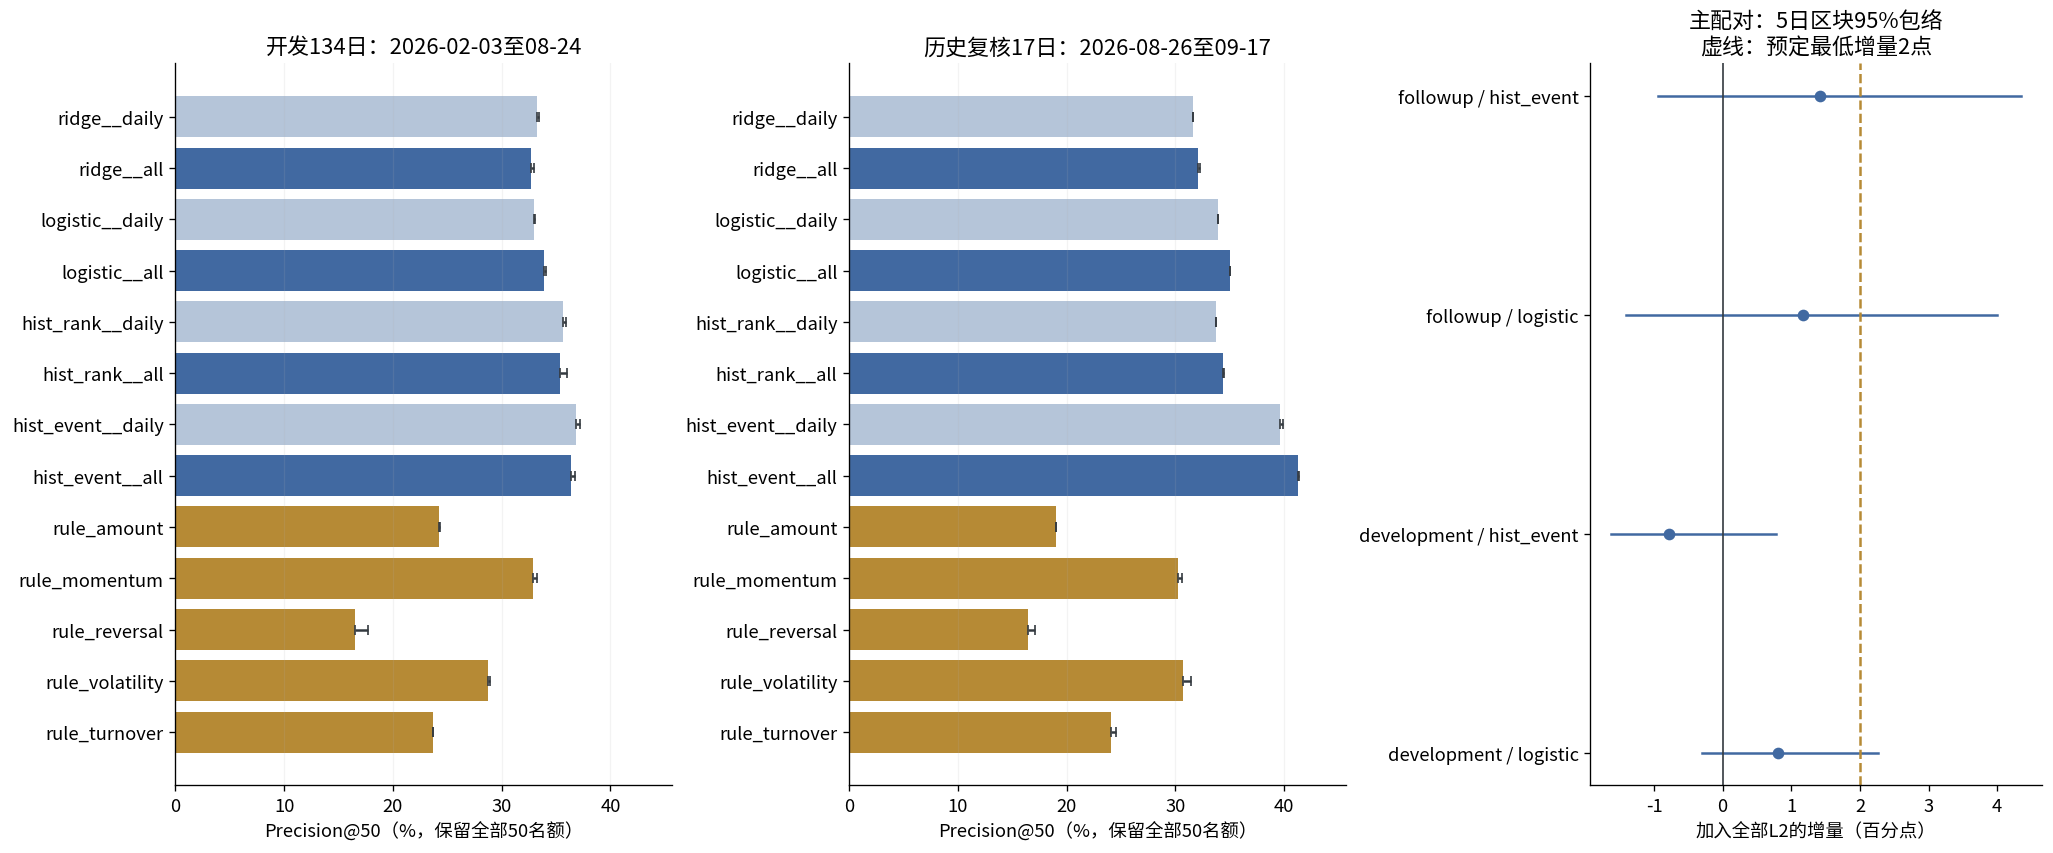

In [7]:
shown = [
    f"{family}__{group}"
    for family in parameters["families"]
    for group in ["daily", "all"]
] + list(rules)
fig, axes = plt.subplots(
    1,
    3,
    figsize=(17, 7),
    layout="constrained",
    gridspec_kw={"width_ratios": [1.1, 1.1, 1]},
)
for axis, stage, title in [
    (axes[0], "development", "开发134日：2026-02-03至08-24"),
    (axes[1], "followup", "历史复核17日：2026-08-26至09-17"),
]:
    rows = summary.loc[stage].loc[shown]
    colors = [
        "#4169a1"
        if name.endswith("__all")
        else "#b5c5d9"
        if "__" in name
        else "#b68a35"
        for name in shown
    ]
    axis.barh(shown, rows.precision_lower * 100, color=colors)
    axis.errorbar(
        rows.precision_lower * 100,
        np.arange(len(rows)),
        xerr=np.array(
            [np.zeros(len(rows)), (rows.precision_upper - rows.precision_lower) * 100]
        ),
        fmt="none",
        color="#343a40",
        capsize=3,
    )
    axis.invert_yaxis()
    axis.set(
        xlabel="Precision@50（%，保留全部50名额）",
        title=title,
        xlim=(0, max(summary.precision_upper) * 110),
    )
    axis.grid(axis="x", alpha=0.15)
primary = intervals.loc[
    intervals.block.eq(5)
    & intervals.contrast.isin(["l2:logistic:all", "l2:hist_event:all"])
].copy()
for position, row in enumerate(primary.itertuples()):
    axes[2].plot(
        [row.lower_025 * 100, row.upper_975 * 100],
        [position, position],
        color="#4169a1",
    )
    axes[2].plot(row.lower_mean * 100, position, "o", color="#4169a1")
axes[2].set_yticks(
    range(len(primary)),
    [f"{r.stage} / {r.contrast.split(':')[1]}" for r in primary.itertuples()],
)
axes[2].axvline(0, color="#343a40", lw=1)
axes[2].axvline(
    parameters["minimum_increment"] * 100,
    color="#b68a35",
    ls="--",
    label="预定最低增量2点",
)
axes[2].set(
    xlabel="加入全部L2的增量（百分点）",
    title="主配对：5日区块95%包络\n虚线：预定最低增量2点",
)
fig.savefig(evidence / "objective-and-increment.png", bbox_inches="tight")
plt.show()

## 8. 分组消融、月度稳定性和校准

每个L2组都与相同学习器daily重新拟合配对；组间高度相关时，不能将单列重要性解释为独立贡献。
月图使用原全池top50，不在月份或组内重新选择。校准图只显示有观测的固定概率箱，空箱保持缺失。
高概率尾箱可能只有数个样本，图中对少于100个已知标签的箱标注n；不将稀疏尾箱解释为可靠校准证据。

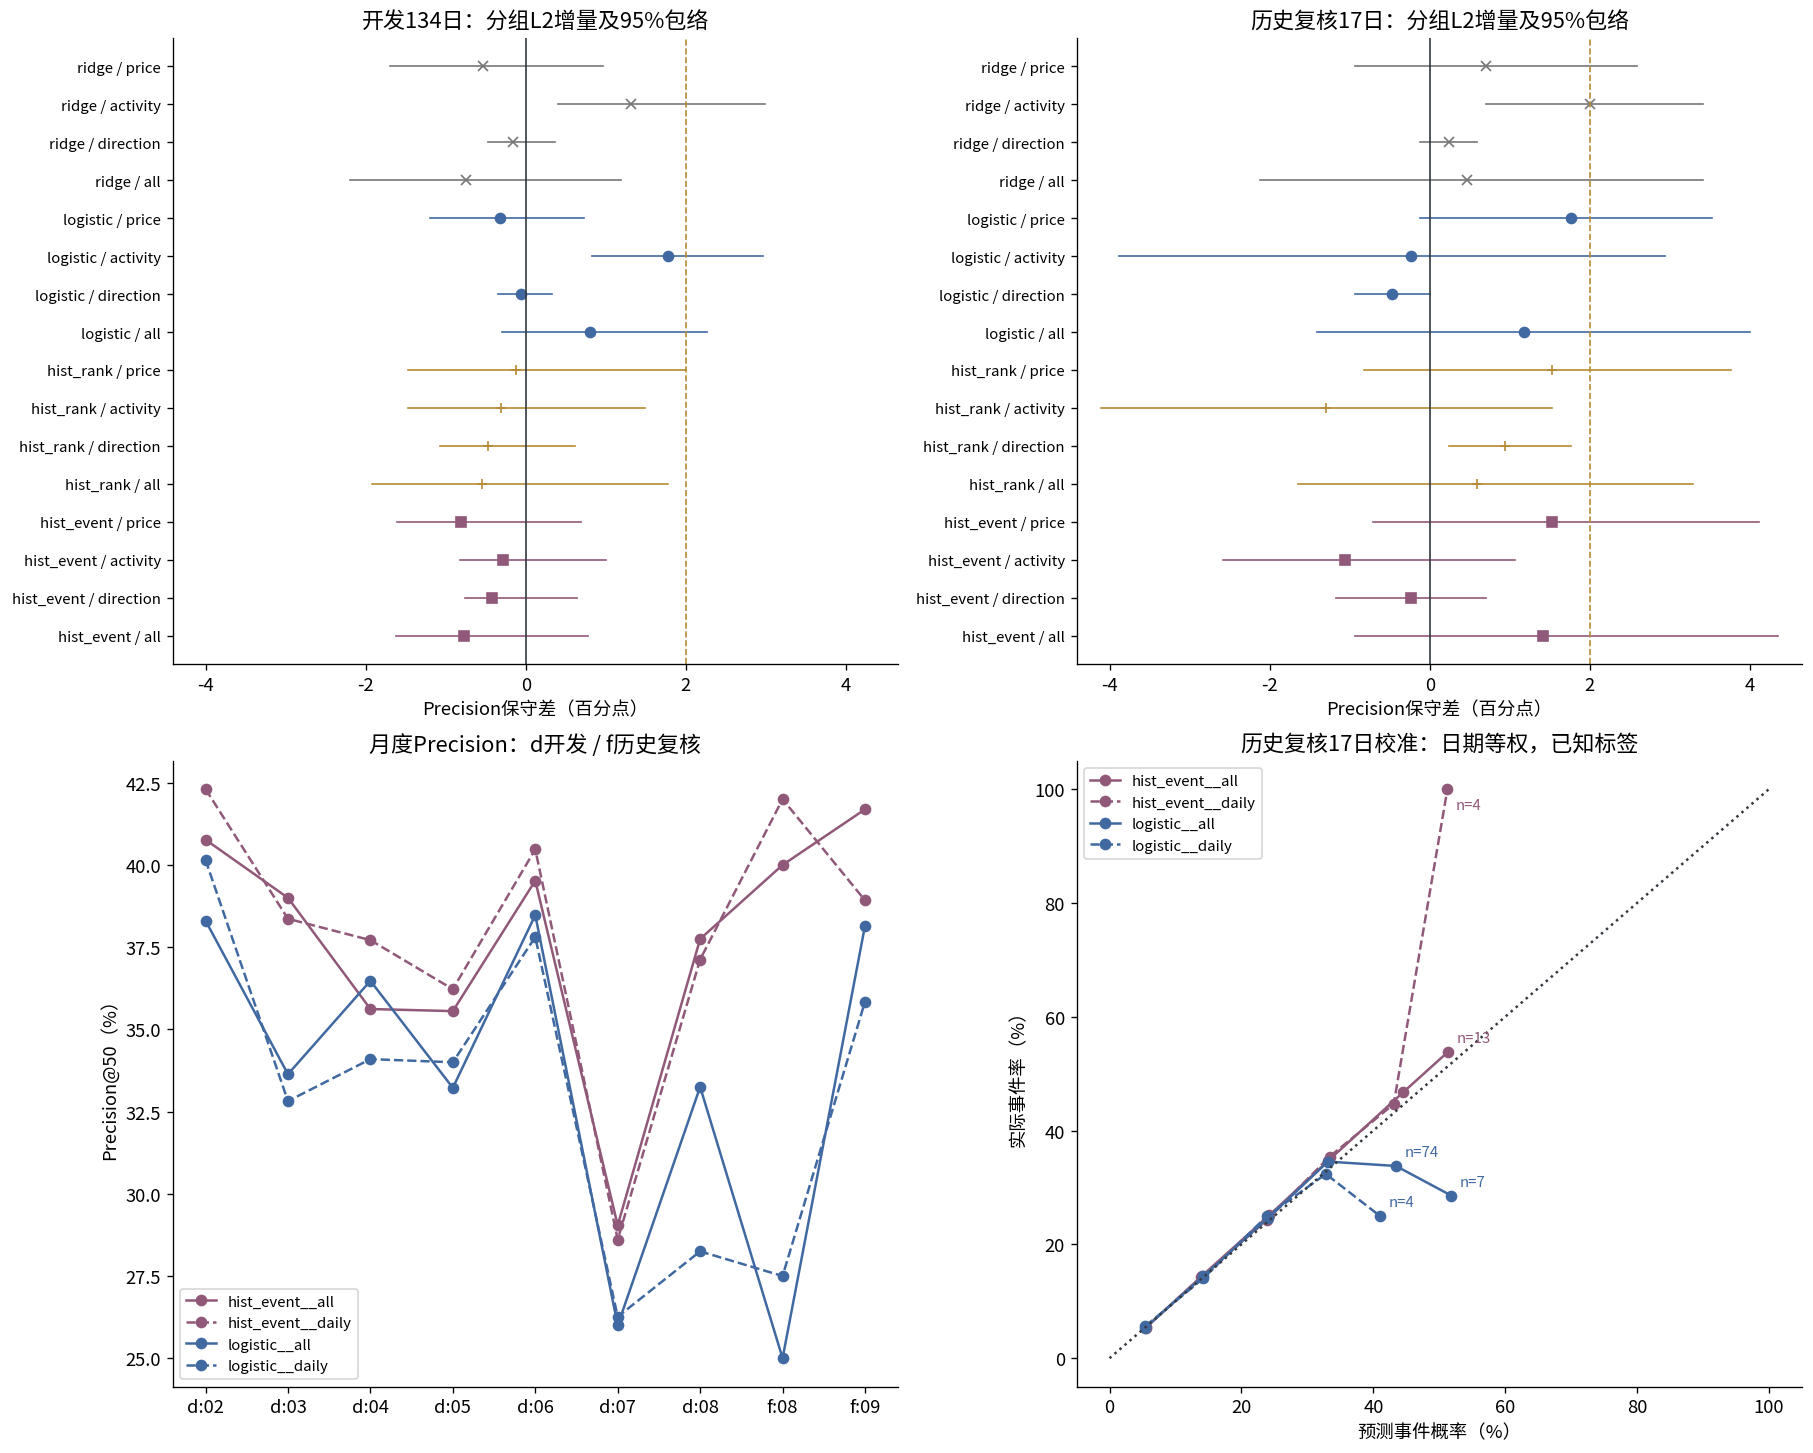

,,coverage,brier,log_loss
stage,method,,,
development,logistic__daily,0.99852,0.08496,0.29934
followup,logistic__daily,0.99906,0.08527,0.30087
development,logistic__all,0.99852,0.08422,0.29554
followup,logistic__all,0.99906,0.08441,0.29677
development,hist_event__daily,0.99852,0.08423,0.29556
followup,hist_event__daily,0.99906,0.08447,0.29679
development,hist_event__all,0.99852,0.08394,0.29420
followup,hist_event__all,0.99906,0.08401,0.29486
development,prior_probability,0.99852,0.08999,0.32507


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12), layout="constrained")
l2_rows = intervals.loc[
    intervals.block.eq(5) & intervals.contrast.str.startswith("l2:")
]
shared_limits = (
    l2_rows.lower_025.min() * 100 - 0.3,
    l2_rows.upper_975.max() * 100 + 0.3,
)
for axis, stage, title in [
    (axes[0, 0], "development", "开发134日：分组L2增量及95%包络"),
    (axes[0, 1], "followup", "历史复核17日：分组L2增量及95%包络"),
]:
    rows = l2_rows.loc[l2_rows.stage.eq(stage)].set_index("contrast")
    names: list[str] = []
    positions: list[int] = []
    for family, color, marker in [
        ("ridge", "#777777", "x"),
        ("logistic", "#4169a1", "o"),
        ("hist_rank", "#b68a35", "+"),
        ("hist_event", "#915979", "s"),
    ]:
        for group in ["price", "activity", "direction", "all"]:
            row = rows.loc[f"l2:{family}:{group}"]
            position = len(names)
            axis.plot(
                [row.lower_025 * 100, row.upper_975 * 100],
                [position, position],
                color=color,
                lw=1,
            )
            axis.plot(row.lower_mean * 100, position, color=color, marker=marker)
            names.append(f"{family} / {group}")
            positions.append(position)
    axis.set_yticks(positions, names, fontsize=9)
    axis.invert_yaxis()
    axis.axvline(0, color="#343a40", lw=1)
    axis.axvline(2, color="#b68a35", ls="--", lw=1)
    axis.set(title=title, xlabel="Precision保守差（百分点）", xlim=shared_limits)
for method, color, style in [
    ("hist_event__all", "#915979", "-"),
    ("hist_event__daily", "#915979", "--"),
    ("logistic__all", "#4169a1", "-"),
    ("logistic__daily", "#4169a1", "--"),
]:
    month_rows = monthly.reset_index()
    month_rows = month_rows.loc[month_rows.method.eq(method)]
    axes[1, 0].plot(
        month_rows["stage"].str[0] + ":" + month_rows["month"].str[5:],
        month_rows.precision_lower * 100,
        color=color,
        ls=style,
        marker="o",
        label=method,
    )
    curve = calibration.loc[("followup", method)]
    axes[1, 1].plot(
        curve.predicted * 100,
        curve.observed * 100,
        color=color,
        ls=style,
        marker="o",
        label=method,
    )
    for bin_row in curve.loc[curve["count"].between(1, 99)].itertuples():
        axes[1, 1].annotate(
            f"n={int(bin_row.count)}",
            (bin_row.predicted * 100, bin_row.observed * 100),
            xytext=(5, -12 if bin_row.observed > 0.9 else 6),
            textcoords="offset points",
            color=color,
            fontsize=9,
        )
axes[1, 0].set(title="月度Precision：d开发 / f历史复核", ylabel="Precision@50（%）")
axes[1, 0].legend(fontsize=9)
axes[1, 1].plot([0, 100], [0, 100], color="#343a40", ls=":")
axes[1, 1].set(
    title="历史复核17日校准：日期等权，已知标签",
    xlabel="预测事件概率（%）",
    ylabel="实际事件率（%）",
)
axes[1, 1].legend(fontsize=9)
fig.savefig(evidence / "groups-and-calibration.png", bbox_inches="tight")
plt.show()
display(
    probability_summary.loc[
        (
            slice(None),
            [
                "logistic__daily",
                "logistic__all",
                "hist_event__daily",
                "hist_event__all",
                "prior_probability",
            ],
        ),
        ["coverage", "brier", "log_loss"],
    ].round(5)
)

## 9. 保留全部证据与判断边界

严格按运行前条件计算候选筛选结果，不自动adoption。分组汇总的命中贡献以原50名额为分母，
组内命中率另外列出；证券代码分组不等于行业。全部原输入运行后再次检查哈希。
源码、依赖锁、输入、模型、全池预测、名单、每日计数、校准箱与bootstrap均可恢复。

分组事实：复核段，浅树日频排名回归的高波动20%组占名额90.94%，事件分类为64.12%，
加入全部L2的事件分类为62.71%。所有波动/流动性/代码前缀组的名额、命中与未知数见
`subgroups.parquet` 和 `subgroup-summary.csv`；组内比率按该组名额汇总。


In [9]:
subgroup_summary = subgroups.groupby(["stage", "method", "dimension", "group"]).agg(
    days=("trade_date", "size"),
    pool=("pool", "sum"),
    selected=("selected", "sum"),
    hits=("hits", "sum"),
    unknown=("unknown", "sum"),
    pool_known=("pool_known", "sum"),
    pool_events=("pool_events", "sum"),
)
subgroup_summary["allocation_share"] = subgroup_summary.selected / (
    subgroup_summary.days * parameters["k"]
)
subgroup_summary["hit_contribution"] = subgroup_summary.hits / (
    subgroup_summary.days * parameters["k"]
)
subgroup_summary["selected_precision"] = (
    subgroup_summary.hits / subgroup_summary.selected.replace(0, np.nan)
)
subgroup_summary["pool_event_rate"] = (
    subgroup_summary.pool_events / subgroup_summary.pool_known.replace(0, np.nan)
)
subgroup_summary.to_csv(evidence / "subgroup-summary.csv")
judgements = []
for family in ["logistic", "hist_event"]:
    rows = primary.loc[primary.contrast.eq(f"l2:{family}:all")]
    assert len(rows) == 2
    judgements.append(
        {
            "family": family,
            "both_periods_pass": bool(
                (
                    (rows.lower_mean >= parameters["minimum_increment"])
                    & (rows.primary_bonferroni_lower > 0)
                ).all()
            ),
            "development_excludes_2pp": bool(
                rows.loc[rows.stage.eq("development"), "upper_95"].iloc[0]
                < parameters["minimum_increment"]
            ),
            "followup_excludes_2pp": bool(
                rows.loc[rows.stage.eq("followup"), "upper_95"].iloc[0]
                < parameters["minimum_increment"]
            ),
        }
    )
for input_record in input_records:
    assert _sha256(Path(input_record["source"])) == input_record["sha256"]
    assert _sha256(inputs / input_record["path"]) == input_record["sha256"]
_write_json(
    evidence / "result.json",
    {
        "judgements": judgements,
        "strongest_rule": strongest_rule,
        "fits": len(fit_records),
        "input_files": len(input_records),
        "inputs_unchanged": True,
        "independent_final": False,
        "verification": verification,
    },
)
artifact_records = [
    {
        "path": str(path.relative_to(evidence)),
        "sha256": _sha256(path),
        "size_bytes": path.stat().st_size,
    }
    for path in sorted(evidence.rglob("*"))
    if path.is_file() and path.name != "execution-checkpoint.ipynb"
]
_write_json(evidence / "artifact-manifest.json", artifact_records)
display(pd.DataFrame(judgements))
print(f"证据目录：{evidence}")

,family,both_periods_pass,development_excludes_2pp,followup_excludes_2pp
0,logistic,False,False,False
1,hist_event,False,True,False


证据目录：/home/wsw/app/research-evidence/subscription-event-2026-09-23-00ysvads


<a id="h07-protocol"></a>

## H07 2026-09-23 冻结方案与验收

运行前完整记录：[冻结 README](/home/wsw/app/research-evidence/subscription-event-2026-09-23-00ysvads/preregistered-README.md)。以下为便于阅读迁入的说明，原冻结记录不回写。

- 输入仅来自 `subscription-next-high-2026-09-22-mg7mzsz2`，校验其归档哈希并复制。
  目标日仍为 `2025-11-06..2026-09-17`；开发134日 `02-03..08-24`、历史复核17日
  `08-26..09-17`；`08-25` 不参加评价。两段均已消费，**本轮没有独立最终验证集**。
  不读取新日期结果，不将分组切片或重复训练冒充独立确认。
- 保持 `high_rank > 0.9`、原样本、K=50、同分按 symbol、缺失填0.5、日期等权且均值1
  的拟合权重。只用成熟的已知标签拟合，所有事前池行均推理，不因未来标签缺失补选。
  扩展历史至少60个合法日期，首次评价及以后月首08:00拟合；P 22:00输入可用、T 09:00
  模型就绪仍是历史情景假设。8月模型跨开发/复核边界延续，9月只按月首更新。
- 四种固定学习器、五种固定输入，共20配置；不调参、不重选训练窗口：
  - Ridge 排名回归：`alpha=100, solver=cholesky`，恢复 H06 相同配置作锚点。
  - LogisticRegression 事件概率：`C=0.01, solver=lbfgs, max_iter=1000, tol=1e-8`，
    L2正则、无类别重加权。它与 Ridge 的比较同时涉及损失/链接，不能视为严格只换损失。
  - HistGradientBoostingRegressor 排名回归及 HistGradientBoostingClassifier 事件概率：
    均为100轮、7叶、深度3、叶最少500行、学习率0.05、L2=10、63 bins、关闭
    early stopping、seed=20260919；同结构配对用于核对目标变化。
  - 五种输入：日频7列；日频＋价格/振幅8列；日频＋活跃度/规模16列（含4列覆盖比）；
    日频＋方向代理8列；日频＋全部32列L2。四窗口全保留，列顺序沿用 H06。
- 五项简单规则：原成交额、动量、反向动量，以及60日波动率分位、20日平均换手分位。
  开发段按 Precision 下界均值固定最强规则，同分按名称；查看17日结果前落盘。
  20模型与全部五规则均披露，不按历史复核结果另选赢家。
- 主问题为两分类器全部L2减各自日频的 Precision@50；其余分组增量、分类减对应回归、
  L2增量的差中差、相对最强规则均为预定诊断。报告日期等权缺失上下界、Recall/F1/Lift、
  概率 Brier/log loss、固定十等宽箱校准；回归分数不冒充事件概率。
  概率损失只在已知标签上计算，比较同一已知集合，另列只用拟合历史的日期等权事件率基线。
- 5日循环区块配对bootstrap 10,000次，seed=20260923；1/3日只作敏感性。保守下差为
  候选下界减对照上界，上差反向；展示两侧缺失界的区间包络。两项主比较另外报告
  Bonferroni单侧97.5%下界；所有历史名义区间仍不是独立确认。
- 最低有用增量预定为 Precision **+2个百分点**，即每天50只多命中1只，仅是研究筛选
  门槛，非经济盈亏门槛。两段均达到该均值且主比较校正下界>0，才称“值得独立确认的
  稳定候选”；只一段通过或区间跨零均不称稳定。只有增量上界的单侧95%上限低于2点，
  才能在当前候选/历史情景下排除该量级，不能从不显著推导等效或普遍无用。
- 预定分组：月份；昨日波动率/成交额分位的低20%、中60%、高20%及缺失组；证券代码
  前两位（仅代码分组，不冒充行业分类）。报告原top50的分配与命中贡献，不在组内重选。
- Acceptance: 来源及副本哈希一致、面板key/列/日期/标签映射一致、训练时序与原日程相同；
  Ridge日频/全部L2名单和预测恢复 H06；模型重载恢复全部预测；名单和计数独立重算；
  sklearn复算指标及概率损失；缺失边界反例、标签不影响选池、bootstrap独立重算通过；
  Notebook从头执行，图表和结果可读。统计失败原样保留。
- Stop: 固定20配置各按既定月度日程运行一次；只修技术错误并保存失败证据，不按结果追加
  配置、数据或门槛。无新独立信息时停止在探索性判断，不宣称确认或自动采用。

2026-09-23 的实验缘起：

- Why: 用户于2026-09-23要求按 H06 后续方向及区分原因的方法验证；本轮执行该节建议
  的首项及现有特征消融，避免同时改标签、历史覆盖、特征表达和模型。


<a id="h07-evidence"></a>

## H07 2026-09-23 结果、原因区分与归档

首轮完整执行见 [`event_probability.ipynb`](event_probability.ipynb)。沿用 H06 原面板
1,103,651个股票日及1,534个未知标签，开发/历史复核分别保留6,700/850个入选名额。
下表均为日期等权 Precision 下界；未知仍参与分母。

| 学习器 | 日频：开发134日 | 全部L2：开发134日 | 日频：历史复核17日 | 全部L2：历史复核17日 |
| --- | ---: | ---: | ---: | ---: |
| Ridge排名回归（H06锚点） | 33.2985% | 32.6866% | 31.6471% | 32.1176% |
| Logistic事件概率 | 33.0000% | 33.8806% | 33.8824% | 35.0588% |
| 浅树排名回归 | 35.6119% | 35.3284% | 33.7647% | 34.3529% |
| 浅树事件概率 | **36.8657%** | 36.4030% | **39.6471%** | **41.2941%** |

最强简单规则按开发段冻结为动量，开发32.8806%、历史复核30.2353%（后者上界30.5882%）。
波动率规则为28.7910%/30.7059%，换手规则23.6716%/24.1176%，成交额24.2687%/19.0588%，
反向动量16.4925%/16.4706%。复核段没有换用新的规则赢家。浅树事件概率纯日频相对冻结
动量规则的保守差为开发+3.6119点、复核+9.0588点，5日区块95%包络分别为
[+1.5672,+6.2388]、[+5.5294,+13.8824]点；支持超过这组事前简单规则的历史表现，
不能外推为超过所有日频方法。

**训练目标与 L2 必须分开判断。** 同复杂度浅树的纯日频分类相对排名回归，复核多命中
50次（337对287）；考虑分类的两个未知标签，增量界为[+5.8824,+6.1176]点，
5日区块95%包络[+2.2353,+10.0000]点。开发段的相应包络却为[−0.3731,+2.9851]点，
不能称为跨期已确认优势。分类改善在没有L2时也出现；这支持优先对齐事件评价目标，
并未证明改善必须来自L2。

| 全部L2减同学习器日频 | 开发增量界（点） | 开发95%包络（点） | 复核增量界（点） | 复核95%包络（点） |
| --- | ---: | ---: | ---: | ---: |
| Logistic | [+0.8060,+1.0896] | [−0.2985,+2.2687] | +1.1765 | [−1.4118,+4.0000] |
| 浅树事件概率 | [−0.7761,−0.1194] | [−1.6269,+0.7761] | [+1.4118,+1.7647] | [−0.9412,+4.3529] |

两分类器均未达到“两段保守均值≥2点且主比较校正下界>0”。浅树全部L2在开发段相对
日频的增量上界之单侧95%上限仅+0.6418点，可以在当前历史情景下排除2点量级；
复核段该上限仍为4点，不能排除有用改善，也不能证明等效。
分类与对应回归的L2增量差中差，两段区间均跨零；因此没有识别出“改学事件概率就能
稳定释放现有整组L2增量”。

**分组消融提供了较窄的线索。** Ridge只加活跃度/规模组时，开发命中率34.7463%、
复核33.6471%；相对日频的保守差分别+1.3134、+2.0000点，95%包络为
[+0.4030,+2.9851]、[+0.7059,+3.4118]点。它优于原来整组加入的历史结果，说明组合方式
值得注意，但开发增量未达到2点门槛，不能据此宣称已经找到稳定候选。
Logistic活跃度组的开发增量+1.7761点，在复核转为−0.2353点；浅树价格组在复核为正、
开发为负，方向组也未显示一致改善。删减相关列会改变模型拟合及正则作用，这些结果
不能单独证明该组含有不可替代的信息，更不支持“全部L2本身无用”。

**其他固定诊断。** 两分类器加L2后，全池已知标签的Brier/log loss在两段的点估计均下降。
例如浅树复核Brier从0.084471降至0.084015，log loss从0.296792降至0.294863；
Logistic分别从0.085268降至0.084409、从0.300871降至0.296767。概率误差改善不等于
top50增量通过；这些损失没有另作确认性检验。高概率尾箱仅4至13个样本的情况已在图中
标注，不能将其当成精确校准证据。

浅树全部L2减日频的开发月度点差，七个月中四负三正；复核8月四日为−2点，9月十三日
为+2.7692点。波动率、成交额分位及代码前缀的全部分配/命中表保存在归档。
复核段浅树日频排名回归的高波动20%组占入选名额90.94%，事件分类为64.12%；
其余主要转向中间波动组。加入全部L2的事件分类该占比为62.71%。这些是事前特征下的
名单变化，不能由此推断具体股票的因果贡献。代码前缀切片没有行业信息，不冒充行业诊断。

**Evidence 与工程复核。** 最终归档为
`/home/wsw/app/research-evidence/subscription-event-2026-09-23-00ysvads/`，保留至用户决定
及审查结束。基线commit为 `46ecdc1dba1a390cf7cfe8560f296cb7fcd0cbbf`，实际代码由
`source.tar`、`source-event_probability.ipynb` 和 `run.json` 绑定，最终可读版本为
`event_probability.ipynb`/`event_probability.html`。177份冻结输入共389,325,816字节，
源/副本在运行后哈希均未变；不读取新日期或写入正式数据。

Notebook从头执行9个代码单元；160个模型恢复全部3,020组模型日预测，独立核对3,775组
名单/命中计数和1,661组概率损失。570组原H06回归预测逐值恢复；Ridge的成熟训练日期、
拟合及假定就绪时间与原日程一致。未知赋值枚举、严格0.9边界、同分/缺失排序及标签不影响
选池反例通过；两主比较在三个区块长度、两个时期的全部重采样由独立循环复算。
相关预处理/数据集/推理测试13 passed；最终Notebook的Ruff、格式检查及导出代码定向Mypy
通过。完成后仅补绘图局部列表的类型标注及文字摘要，未改变计算。已检查原图及HTML呈现。

首轮完整运行保存在同级 `subscription-event-2026-09-23-jq79mit_/`；最终运行的323份
模型、预测及数值结果与首轮逐字节一致，见 `repeat-checks.json`。图表改版中间一次复跑因
绘图缩排错误在训练阶段主动中断，源码、部分模型及错误保存在同级 `dugf5i0x` 结尾目录；
修复后按相同候选/参数从头运行，没有利用中断改变候选。复跑不是独立实验。
未运行无关的全仓库测试，未重新核验raw经济真实性或历史修订版本当时是否可得。


<a id="h07-reproduce"></a>

## H07 复跑与证据检查

H07使用 `event_probability.ipynb`；在仓库根、指向项目锁定Python 3.13的内核中从头执行，
会只读H06归档并创建新的隔离证据目录。精确恢复时将H07的 `source.tar` 解入独立源码目录，
并使用归档的最终Notebook。若不再读取H06原路径，把 `prior` 指向H07归档的 `inputs/` 副本，
先将归档中的 `NotoSansCJKsc-Regular.otf` 复制进该独立输入目录；保留内含的H06原
`artifact-manifest.json`。这177份输入已包含面板、标签、日期、锚点预测和日程，不需要
复制raw、分钟事实或创建正式存储根。输出中的 `parameters.json`、`features.json`、
`fit-schedule.json`、`strongest-rule-frozen.json`、`verification.json` 及完整数值表用于复核；
`final-artifact-manifest.json` 绑定最终源码、结果和展示文件。恢复仅用于复算，不新增验证样本。
